# RL Group Project: Starter Notebook
## Clinical Treatment Optimisation: Sepsis ICU Management

**Master in Data Science & Advanced Analytics — Reinforcement Learning Course**

This project is structured in two stages of increasing complexity.

- In **Configuration A**, you will work with a tabular Sepsis MDP, where the state and action spaces are small enough to apply classical RL methods directly.

- In **Configuration B**, you will move to a continuous-observation ICU environment that is clinically grounded and significantly more challenging.

Three realistic failure modes are present in Configuration B, each reflecting a real scenario encountered in clinical AI deployments. The first is episodic observation noise, where monitoring equipment occasionally malfunctions. The second is episodic missing observations, representing situations where lab results are simply unavailable for an entire episode. The third is acute clinical events, which are sudden and irreversible patient deteriorations that occur independently of any treatment given.

---
### Group Members
Group V

```
Student 1: Alano Gonçalves 20250457
Student 2: Catarina Martins 20221914
Student 3: João Carichas 20250507
Student 4: Marta Ribeiro 20221886
Student 5: Nicole Nogueira 20221961
```


## 0. Setup & Imports


In [1]:
# Install dependencies (run once)
#!pip install icu-sepsis numpy pandas matplotlib seaborn tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import os
from tqdm import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('plots', exist_ok=True)
PLOTS_DIR = 'plots'

SEED = 42
np.random.seed(SEED)

from envs.env_setup import (
    ENV_ID, N_STATES, N_ACTIONS, STATE_SURVIVED, STATE_DIED,
    GAMMA, INTENSITY, SOFA_BIAS, LAM,
    make_sepsis_env,
)

print(f'ICU-Sepsis-v2 | States: {N_STATES} | Actions: {N_ACTIONS}')
print(f'Terminal states: {STATE_SURVIVED} (survived, r=+1)  {STATE_DIED} (died, r=0)')
print('Setup complete!')


ICU-Sepsis-v2 | States: 716 | Actions: 25
Terminal states: 714 (survived, r=+1)  713 (died, r=0)
Setup complete!


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
# Configuration already loaded from env_setup.py
# env_setup.py defines: SOFA_BIAS=5.0, LAM=0.02, INTENSITY, make_sepsis_env()
print(f'Required config: sofa_bias={SOFA_BIAS}, lam={LAM}')


Required config: sofa_bias=5.0, lam=0.02


---
## 1. Explore the Environment

Before writing any algorithm, take time to understand the MDP you are working with. The insights you gain here should inform your report's Methodology section.

`ICU-Sepsis-v2` is a benchmark MDP constructed from real MIMIC-III patient data. Each episode represents the trajectory of one ICU patient. The agent observes a discrete integer state (ranging from 0 to 715) and must select one of 25 treatment actions corresponding to combinations of vasopressor and IV fluid dose levels. The reward signal is sparse: **+1 at survival, 0 at death, and 0 for all intermediate steps**, with a discount factor γ = 1.


In [3]:
#  Instantiate and inspect the raw environment 
env = make_sepsis_env()
obs, info = env.reset(seed=SEED)

print(f'Observation space : {env.observation_space} discrete integer state')
print(f'Action space      : {env.action_space}')
print(f'Initial state     : {obs}')
print()

#  Extract the full MDP model 
raw = env.unwrapped
P      = raw._tx_mat                  # (716, 25, 716) — P[s,a,s'] = P(s'|s,a)
R_sasp = raw._r_mat                   # (716, 25, 716) — R[s, a, s']
R      = (P * R_sasp).sum(axis=2)    # (716, 25)      — E[r | s, a]

print(f'Transition matrix P : {P.shape}  (S x A x S\')')
print(f'Reward matrix R     : {R.shape}  (S x A)')
print(f'Reward range        : [{R.min():.3f}, {R.max():.3f}]')
print()


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Observation space : Discrete(716) discrete integer state
Action space      : Discrete(25)
Initial state     : 559

Transition matrix P : (716, 25, 716)  (S x A x S')
Reward matrix R     : (716, 25)  (S x A)
Reward range        : [-0.020, 0.708]



In [4]:
#  Random baseline: establish the performance floor 
def run_random_baseline(n_episodes=1000, seed=SEED):
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns, lengths = [], []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            obs, r, te, tr, _ = env_eval.step(env_eval.action_space.sample())
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r)
        lengths.append(steps)
    env_eval.close()
    return np.array(returns), np.array(lengths)


rand_returns, rand_lengths = run_random_baseline()
survival_rate = float(np.mean(rand_returns > 0)) * 100

print(f'Random agent ({len(rand_returns)} episodes):')
print(f'  Mean return    : {np.mean(rand_returns):.4f}')
print(f'  Survival rate  : {survival_rate:.1f}%')
print(f'  Mean ep length : {np.mean(rand_lengths):.1f} steps')
print()
print('All Config A algorithms must beat the random baseline.')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Random agent (1000 episodes):
  Mean return    : 0.5912
  Survival rate  : 69.6%
  Mean ep length : 10.4 steps

All Config A algorithms must beat the random baseline.


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


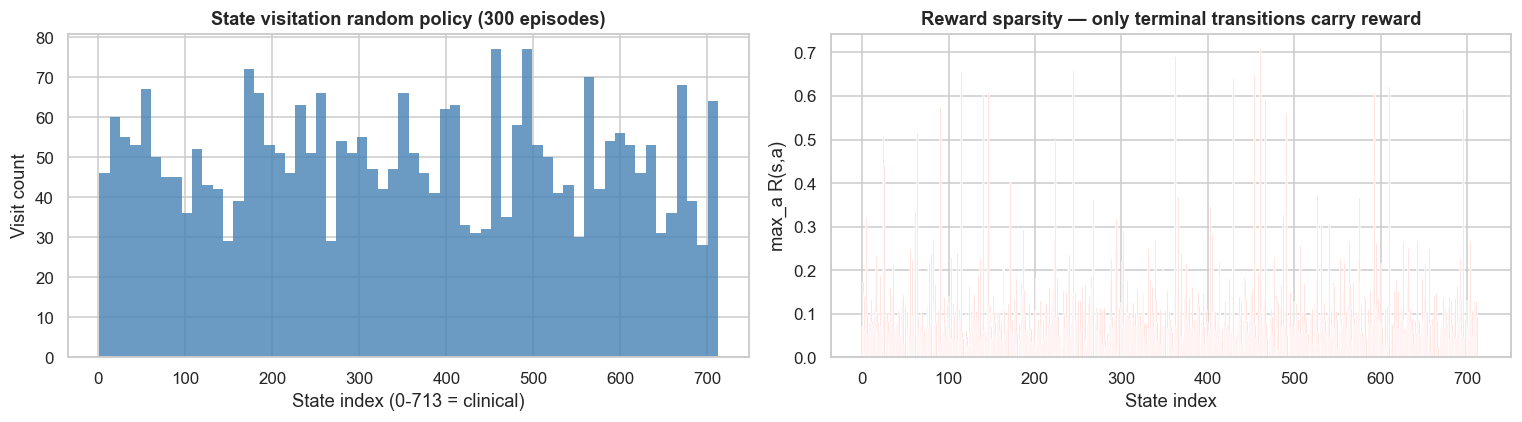

In [5]:
#  Visualise state visitation and reward structure 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

np.random.seed(SEED)
env_vis = make_sepsis_env()
visited = []
for _ in range(300):
    obs, _ = env_vis.reset(seed=np.random.randint(100_000))
    done = False
    while not done:
        visited.append(int(obs))
        obs, _, te, tr, _ = env_vis.step(env_vis.action_space.sample())
        done = te or tr
env_vis.close()
clinical = [s for s in visited if s not in (STATE_SURVIVED, STATE_DIED)]

axes[0].hist(clinical, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('State index (0-713 = clinical)')
axes[0].set_ylabel('Visit count')
axes[0].set_title('State visitation random policy (300 episodes)', fontweight='bold')

axes[1].bar(range(N_STATES), R.max(axis=1), color='tomato', width=1.0, alpha=0.8)
axes[1].set_xlabel('State index')
axes[1].set_ylabel('max_a R(s,a)')
axes[1].set_title('Reward sparsity — only terminal transitions carry reward', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_env_exploration.png', bbox_inches='tight')
plt.show()


---
# Config A — Tabular Methods

With 716 discrete states and 25 actions, the Q-table has shape `(716, 25)`, totalling 17,900 entries. This size is entirely manageable in memory, which is precisely what motivates the use of tabular algorithms here.

We implement three algorithms in Config A:
- **Policy Iteration (PI)**: a model-based Dynamic Programming method that uses the full MDP (transition matrix P and reward matrix R) to find the theoretically optimal policy. Serves as the performance ceiling.
- **SARSA**: an on-policy, model-free TD algorithm. Learns from environment interaction; its updates use the action the agent actually takes next, making it conservative.
- **Q-Learning**: an off-policy, model-free TD algorithm. Also learns from interaction but always updates towards the best possible next action, making it more aggressive.

The natural contrast: **PI** has access to the full model (unfair advantage but gives us the optimal ceiling), while **SARSA and Q-Learning** must discover the policy through trial and error. Within the model-free pair, the **on-policy vs off-policy** distinction maps directly onto clinical conservatism: an agent that accounts for its own exploratory uncertainty (SARSA) vs one that assumes it will always act optimally (Q-Learning).


---
## 2. Policy Iteration — Optimal Benchmark

Policy Iteration is a Dynamic Programming method that alternates between two steps:
1. **Policy Evaluation**: given the current policy, compute V(s) for all states using the Bellman expectation equation iteratively.
2. **Policy Improvement**: for each state, update the policy to the action that maximises the expected value.

Because the full MDP (P and R) is available in Config A, PI finds the exact optimal policy without any interaction with the environment. This makes it the **theoretical ceiling** against which we measure our model-free agents.

> **Note on PI as ceiling:** PI optimises the policy given the reward function and transition matrix P. However, P is estimated from finite MIMIC-III data — so PI optimises over a noisy model. The gap between PI and model-free agents represents both the cost of not having the model AND the noise in P itself.


In [6]:
# ── Policy Iteration ──────────────────────────────────────────────────────────

def policy_iteration(P, R, gamma=1.0, theta=1e-8, max_iter=1000):
    """
    Exact Policy Iteration using the full MDP matrices.

    Parameters
    ----------
    P     : np.ndarray (S, A, S') — transition probabilities
    R     : np.ndarray (S, A)     — expected reward per state-action
    gamma : float                 — discount factor
    theta : float                 — convergence threshold for policy evaluation
    max_iter : int                — max policy improvement iterations

    Returns
    -------
    policy        : np.ndarray (S,) — optimal action per state
    V             : np.ndarray (S,) — optimal value function
    n_iter        : int             — number of policy improvement iterations
    delta_history : list            — max delta per evaluation sweep (for plotting)
    """
    n_states, n_actions, _ = P.shape
    policy = np.zeros(n_states, dtype=int)
    V = np.zeros(n_states)
    delta_history = []

    for iteration in range(max_iter):

        # Step 1: Policy Evaluation
        while True:
            delta = 0.0
            for s in range(n_states):
                a = policy[s]
                v_new = R[s, a] + gamma * np.dot(P[s, a], V)
                delta = max(delta, abs(v_new - V[s]))
                V[s] = v_new
            delta_history.append(delta)
            if delta < theta:
                break

        # Step 2: Policy Improvement
        policy_stable = True
        for s in range(n_states):
            old_action = policy[s]
            Q_s = R[s] + gamma * P[s].dot(V)
            policy[s] = np.argmax(Q_s)
            if old_action != policy[s]:
                policy_stable = False

        if policy_stable:
            print(f'Policy Iteration converged after {iteration + 1} improvement iterations.')
            break

    return policy, V, iteration + 1, delta_history


np.random.seed(SEED)
pi_policy, pi_V, pi_iters, pi_deltas = policy_iteration(P, R, gamma=GAMMA)

print(f'Value function range: [{pi_V.min():.4f}, {pi_V.max():.4f}]')
print(f'Unique actions used by PI policy: {len(np.unique(pi_policy))}/25')


Policy Iteration converged after 4 improvement iterations.
Value function range: [0.0000, 0.9814]
Unique actions used by PI policy: 15/25


In [7]:
# ── Evaluate Policy Iteration ─────────────────────────────────────────────────

def evaluate_policy_tabular(policy_array, n_episodes=1000, seed=SEED):
    """
    Evaluate a deterministic tabular policy over n_episodes.
    Returns dict with mean_return, survival_rate, mean_length.
    """
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns, lengths = [], []

    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            action = int(policy_array[int(obs)])
            obs, r, te, tr, _ = env_eval.step(action)
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r)
        lengths.append(steps)

    env_eval.close()
    returns = np.array(returns)
    return {
        'mean_return'   : float(np.mean(returns)),
        'survival_rate' : float(np.mean(returns > 0)) * 100,
        'mean_length'   : float(np.mean(lengths)),
    }


pi_results = evaluate_policy_tabular(pi_policy)
print('Policy Iteration — Evaluation (1000 episodes):')
print(f'  Mean return   : {pi_results["mean_return"]:.4f}')
print(f'  Survival rate : {pi_results["survival_rate"]:.1f}%')
print(f'  Mean length   : {pi_results["mean_length"]:.1f} steps')
print(f'  vs Random baseline survival: {survival_rate:.1f}%')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Policy Iteration — Evaluation (1000 episodes):
  Mean return   : 0.7507
  Survival rate : 78.8%
  Mean length   : 9.8 steps
  vs Random baseline survival: 69.6%


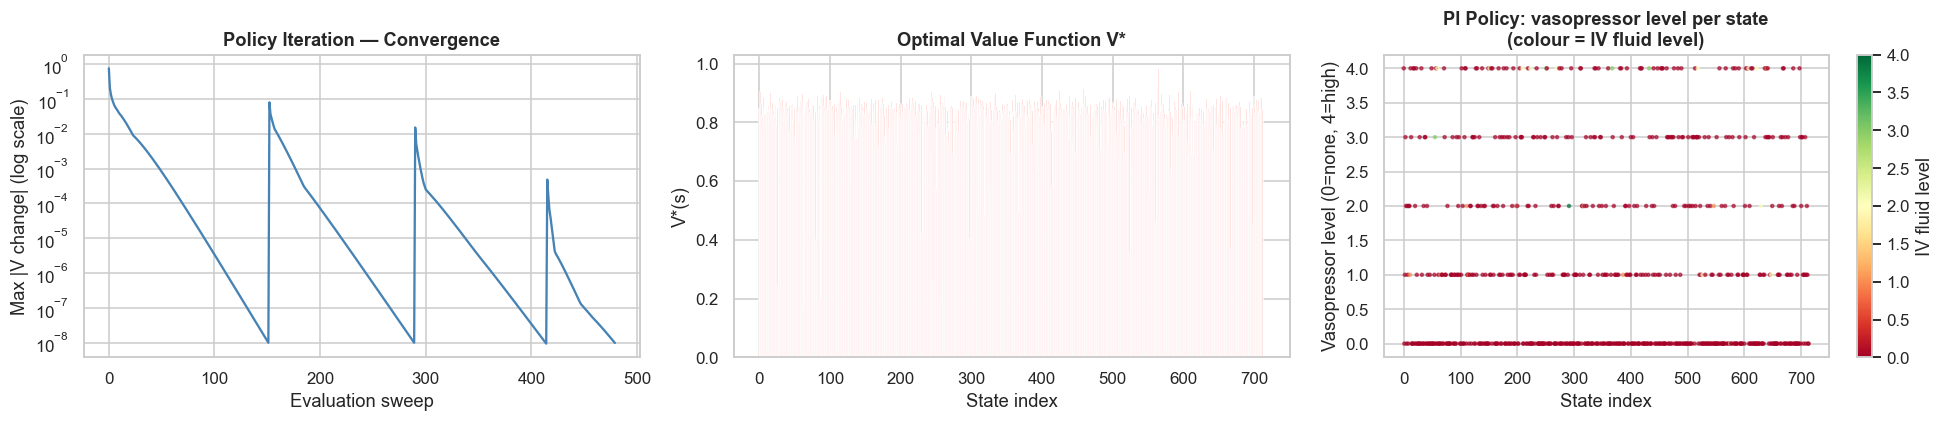

In [8]:
# ── Plot PI: convergence + value function + policy heatmap ───────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].semilogy(pi_deltas, color='steelblue', linewidth=1.5)
axes[0].set_xlabel('Evaluation sweep')
axes[0].set_ylabel('Max |V change| (log scale)')
axes[0].set_title('Policy Iteration — Convergence', fontweight='bold')

clinical_states = [s for s in range(N_STATES) if s not in (STATE_SURVIVED, STATE_DIED)]
axes[1].bar(clinical_states, pi_V[clinical_states], color='tomato', width=1.0, alpha=0.8)
axes[1].set_xlabel('State index')
axes[1].set_ylabel('V*(s)')
axes[1].set_title('Optimal Value Function V*', fontweight='bold')

policy_display = pi_policy[:714]
vaso_levels  = policy_display // 5
fluid_levels = policy_display  % 5
axes[2].scatter(range(len(policy_display)), vaso_levels,
                c=fluid_levels, cmap='RdYlGn', s=4, alpha=0.6)
axes[2].set_xlabel('State index')
axes[2].set_ylabel('Vasopressor level (0=none, 4=high)')
axes[2].set_title('PI Policy: vasopressor level per state\n(colour = IV fluid level)', fontweight='bold')
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(0, 4))
plt.colorbar(sm, ax=axes[2], label='IV fluid level')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_PI.png', bbox_inches='tight')
plt.show()


---
## 3. SARSA — On-Policy TD Control

SARSA (**S**tate–**A**ction–**R**eward–next **S**tate–next **A**ction) is a model-free, on-policy TD control algorithm. At each step it uses the sequence `(s, a, r, s', a')` to update the Q-value:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \bigl[r + \gamma\, Q(s', a') - Q(s,a)\bigr]$$

The key: **a' is selected by the same epsilon-greedy policy** the agent is currently following. This means SARSA's updates account for the risk of future exploratory (random) actions — making it naturally more conservative than Q-Learning. In a clinical context this conservatism is desirable: the agent effectively learns a policy that is safe even while it is still uncertain.


In [9]:
# ── SARSA ─────────────────────────────────────────────────────────────────────

def sarsa(n_episodes=50_000, alpha=0.3, gamma=1.0,
          epsilon_start=1.0, epsilon_min=0.01, seed=SEED):
    """
    SARSA on-policy TD control for the tabular Sepsis MDP.

    Parameters
    ----------
    n_episodes    : int   — number of training episodes
    alpha         : float — learning rate
    gamma         : float — discount factor
    epsilon_start : float — initial exploration probability
    epsilon_min   : float — minimum exploration probability
    seed          : int   — random seed

    Returns
    -------
    Q           : np.ndarray (N_STATES, N_ACTIONS) — learned Q-table
    returns_log : list of float — episode returns during training
    """
    np.random.seed(seed)
    env_train = make_sepsis_env()
    Q = np.zeros((N_STATES, N_ACTIONS))
    returns_log = []
    epsilon = epsilon_start
    decay = (epsilon_start - epsilon_min) / n_episodes

    for ep in tqdm(range(n_episodes), desc='SARSA', leave=False):
        obs, _ = env_train.reset(seed=np.random.randint(100_000))
        s = int(obs)
        if np.random.random() < epsilon:
            a = env_train.action_space.sample()
        else:
            a = int(np.argmax(Q[s]))

        total_r, done = 0.0, False
        while not done:
            obs_next, r, te, tr, _ = env_train.step(a)
            s_next = int(obs_next)
            done = te or tr
            if np.random.random() < epsilon:
                a_next = env_train.action_space.sample()
            else:
                a_next = int(np.argmax(Q[s_next]))
            # SARSA update — uses actual next action
            td_target = r + gamma * Q[s_next, a_next] * (not done)
            Q[s, a] += alpha * (td_target - Q[s, a])
            s, a = s_next, a_next
            total_r += r

        returns_log.append(total_r)
        epsilon = max(epsilon_min, epsilon - decay)

    env_train.close()
    return Q, returns_log


# Run SARSA with default hyperparameters
sarsa_Q, sarsa_returns = sarsa(n_episodes=50_000, alpha=0.3, gamma=GAMMA)
sarsa_policy = np.argmax(sarsa_Q, axis=1)
print('SARSA training complete.')
print(f'Unique actions used: {len(np.unique(sarsa_policy))}/25')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


SARSA training complete.
Unique actions used: 25/25


In [10]:
# ── Evaluate SARSA ────────────────────────────────────────────────────────────
sarsa_results = evaluate_policy_tabular(sarsa_policy)
print('SARSA — Evaluation (1000 episodes):')
print(f'  Mean return   : {sarsa_results["mean_return"]:.4f}')
print(f'  Survival rate : {sarsa_results["survival_rate"]:.1f}%')
print(f'  Mean length   : {sarsa_results["mean_length"]:.1f} steps')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
SARSA — Evaluation (1000 episodes):
  Mean return   : 0.6108
  Survival rate : 70.7%
  Mean length   : 10.4 steps


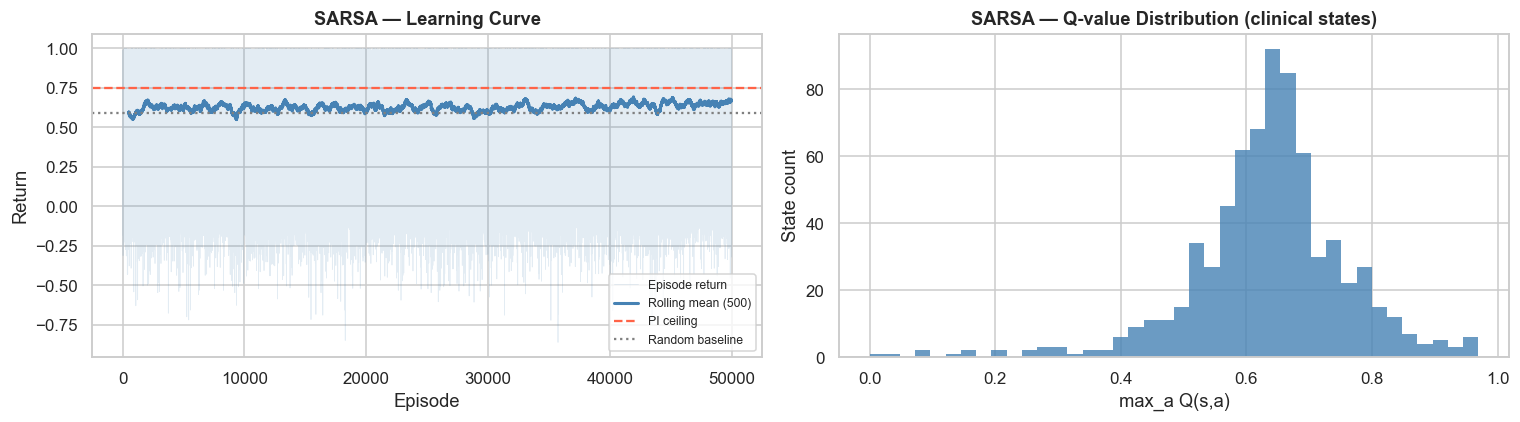

In [11]:
# ── Plot SARSA: learning curve + Q-value distribution ────────────────────────

window = 500
sarsa_rolling = pd.Series(sarsa_returns).rolling(window).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(sarsa_returns, alpha=0.15, color='steelblue', linewidth=0.5, label='Episode return')
axes[0].plot(sarsa_rolling, color='steelblue', linewidth=2.0, label=f'Rolling mean ({window})')
axes[0].axhline(pi_results['mean_return'], color='tomato', linestyle='--', linewidth=1.5, label='PI ceiling')
axes[0].axhline(np.mean(rand_returns), color='gray', linestyle=':', linewidth=1.5, label='Random baseline')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Return')
axes[0].set_title('SARSA — Learning Curve', fontweight='bold')
axes[0].legend(fontsize=8)

max_Q_sarsa = sarsa_Q[:714].max(axis=1)
axes[1].hist(max_Q_sarsa, bins=40, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].set_xlabel('max_a Q(s,a)'); axes[1].set_ylabel('State count')
axes[1].set_title('SARSA — Q-value Distribution (clinical states)', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_SARSA.png', bbox_inches='tight')
plt.show()


---
## 4. Q-Learning — Off-Policy TD Control

Q-Learning is a model-free, **off-policy** TD control algorithm. Its update rule differs from SARSA in one crucial place — instead of using the action the agent actually takes next (`a'`), it always bootstraps from the **maximum** Q-value in the next state:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \bigl[r + \gamma \max_{a'} Q(s', a') - Q(s,a)\bigr]$$

This means Q-Learning learns the value of the **greedy policy** regardless of how the agent actually behaves during training. It tends to converge to a more aggressive optimal policy, but may overestimate Q-values because it always assumes the best possible future (maximisation bias).

In the clinical context: Q-Learning may recommend higher-intensity interventions. Comparing its policy to SARSA's will reveal whether aggressive treatment strategies actually improve survival in this dataset.


In [12]:
# ── Q-Learning ────────────────────────────────────────────────────────────────

def q_learning(n_episodes=50_000, alpha=0.3, gamma=1.0,
               epsilon_start=1.0, epsilon_min=0.01, seed=SEED):
    """
    Q-Learning off-policy TD control for the tabular Sepsis MDP.

    Parameters
    ----------
    n_episodes    : int   — number of training episodes
    alpha         : float — learning rate
    gamma         : float — discount factor
    epsilon_start : float — initial exploration probability
    epsilon_min   : float — minimum exploration probability
    seed          : int   — random seed

    Returns
    -------
    Q           : np.ndarray (N_STATES, N_ACTIONS) — learned Q-table
    returns_log : list of float — episode returns during training
    """
    np.random.seed(seed)
    env_train = make_sepsis_env()
    Q = np.zeros((N_STATES, N_ACTIONS))
    returns_log = []
    epsilon = epsilon_start
    decay = (epsilon_start - epsilon_min) / n_episodes

    for ep in tqdm(range(n_episodes), desc='Q-Learning', leave=False):
        obs, _ = env_train.reset(seed=np.random.randint(100_000))
        s = int(obs)
        total_r, done = 0.0, False

        while not done:
            if np.random.random() < epsilon:
                a = env_train.action_space.sample()
            else:
                a = int(np.argmax(Q[s]))
            obs_next, r, te, tr, _ = env_train.step(a)
            s_next = int(obs_next)
            done = te or tr
            # Q-Learning update — uses max over next actions (off-policy)
            td_target = r + gamma * np.max(Q[s_next]) * (not done)
            Q[s, a] += alpha * (td_target - Q[s, a])
            s = s_next
            total_r += r

        returns_log.append(total_r)
        epsilon = max(epsilon_min, epsilon - decay)

    env_train.close()
    return Q, returns_log


# Run Q-Learning with default hyperparameters
ql_Q, ql_returns = q_learning(n_episodes=50_000, alpha=0.3, gamma=GAMMA)
ql_policy = np.argmax(ql_Q, axis=1)
print('Q-Learning training complete.')
print(f'Unique actions used: {len(np.unique(ql_policy))}/25')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Q-Learning training complete.
Unique actions used: 25/25


In [13]:
# ── Evaluate Q-Learning ───────────────────────────────────────────────────────
ql_results = evaluate_policy_tabular(ql_policy)
print('Q-Learning — Evaluation (1000 episodes):')
print(f'  Mean return   : {ql_results["mean_return"]:.4f}')
print(f'  Survival rate : {ql_results["survival_rate"]:.1f}%')
print(f'  Mean length   : {ql_results["mean_length"]:.1f} steps')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Q-Learning — Evaluation (1000 episodes):
  Mean return   : 0.6617
  Survival rate : 75.1%
  Mean length   : 10.6 steps


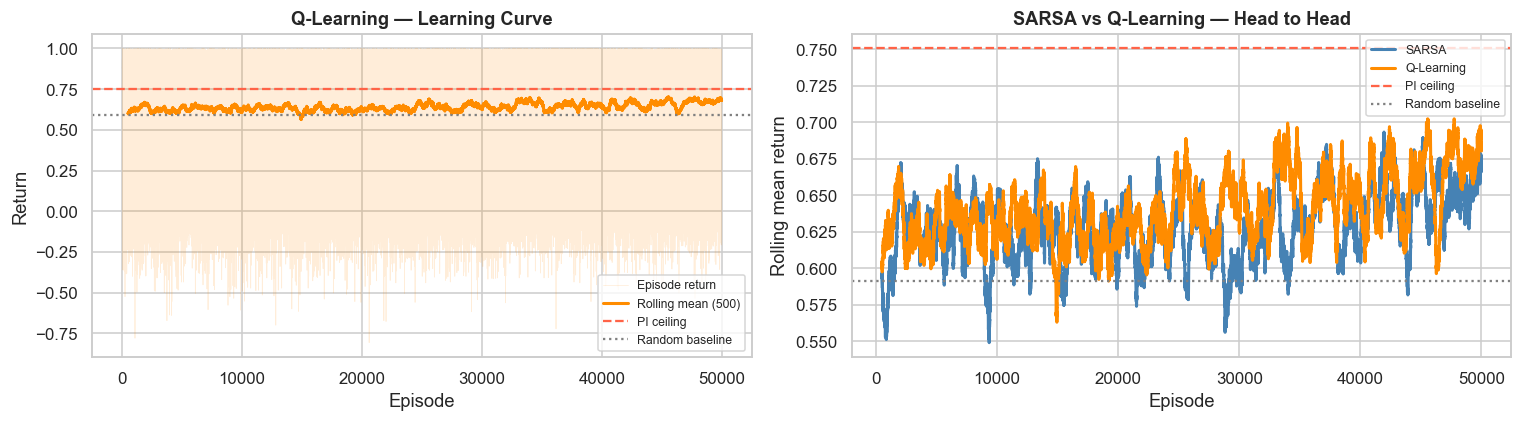

In [14]:
# ── Plot Q-Learning: learning curve + SARSA vs QL overlay ────────────────────

window = 500
ql_rolling         = pd.Series(ql_returns).rolling(window).mean()
sarsa_rolling_full = pd.Series(sarsa_returns).rolling(window).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ql_returns, alpha=0.15, color='darkorange', linewidth=0.5, label='Episode return')
axes[0].plot(ql_rolling, color='darkorange', linewidth=2.0, label=f'Rolling mean ({window})')
axes[0].axhline(pi_results['mean_return'], color='tomato', linestyle='--', linewidth=1.5, label='PI ceiling')
axes[0].axhline(np.mean(rand_returns), color='gray', linestyle=':', linewidth=1.5, label='Random baseline')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Return')
axes[0].set_title('Q-Learning — Learning Curve', fontweight='bold')
axes[0].legend(fontsize=8)

axes[1].plot(sarsa_rolling_full, color='steelblue', linewidth=2.0, label='SARSA')
axes[1].plot(ql_rolling, color='darkorange', linewidth=2.0, label='Q-Learning')
axes[1].axhline(pi_results['mean_return'], color='tomato', linestyle='--', linewidth=1.5, label='PI ceiling')
axes[1].axhline(np.mean(rand_returns), color='gray', linestyle=':', linewidth=1.5, label='Random baseline')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Rolling mean return')
axes[1].set_title('SARSA vs Q-Learning — Head to Head', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_QL.png', bbox_inches='tight')
plt.show()


---
## 5. Hyperparameter Optimisation

The model-free agents in Sections 3 and 4 used default hyperparameters (alpha=0.3) and only 50,000 episodes. Looking at the learning curves, both agents were still improving at the end of training — they had not fully converged yet.

We run a focused optimisation with two goals:
1. **Alpha grid search** for **both** SARSA and Q-Learning at 200k episodes — both algorithms are tuned under identical conditions so the comparison is fair.
2. **Final optimised run** using the best alpha found for each algorithm at 500k episodes — bringing Q-Learning as close to the PI ceiling as possible.
3. **Stability analysis** — because in a clinical setting, a consistent policy matters as much as a high average survival rate.

> **Note on PI as the ceiling:** PI optimises over the full transition matrix P, which is estimated from finite data. The remaining gap between the best model-free agent and PI is the irreducible cost of not having the model — not something more training can fully close.


In [15]:
# ── Alpha grid search: SARSA and Q-Learning, 200k episodes ──────────────────
# Both algorithms tested under identical conditions (same episodes, same alphas, same seed)
# Q-tables are stored to avoid retraining in the stability section below

alpha_values    = [0.05, 0.1, 0.2, 0.3, 0.5]
N_OPT_EPISODES  = 200_000

alpha_grid_results = {}   # keyed by (algo_name, alpha)
alpha_grid_returns = {}
alpha_grid_Qtables = {}   # store Q-tables to avoid retraining later

for algo_name, algo_fn in [('SARSA', sarsa), ('Q-Learning', q_learning)]:
    print(f'\n── {algo_name} ──')
    for alpha_val in alpha_values:
        print(f'  alpha={alpha_val} | {N_OPT_EPISODES:,} episodes...', end=' ', flush=True)
        Q_tmp, returns_tmp = algo_fn(
            n_episodes=N_OPT_EPISODES,
            alpha=alpha_val,
            gamma=GAMMA,
            epsilon_start=1.0,
            epsilon_min=0.01,
            seed=SEED,
        )
        policy_tmp  = np.argmax(Q_tmp, axis=1)
        results_tmp = evaluate_policy_tabular(policy_tmp)
        alpha_grid_results[(algo_name, alpha_val)] = results_tmp
        alpha_grid_returns[(algo_name, alpha_val)] = returns_tmp
        alpha_grid_Qtables[(algo_name, alpha_val)] = Q_tmp   # store for reuse
        print(f'survival={results_tmp["survival_rate"]:.1f}%  return={results_tmp["mean_return"]:.4f}')

# Best alpha per algorithm
best_alpha_sarsa = max(alpha_values,
    key=lambda a: alpha_grid_results[('SARSA', a)]['survival_rate'])
best_alpha_ql    = max(alpha_values,
    key=lambda a: alpha_grid_results[('Q-Learning', a)]['survival_rate'])

print(f'\nBest alpha — SARSA      : {best_alpha_sarsa} '
      f'({alpha_grid_results[("SARSA", best_alpha_sarsa)]["survival_rate"]:.1f}%)')
print(f'Best alpha — Q-Learning : {best_alpha_ql} '
      f'({alpha_grid_results[("Q-Learning", best_alpha_ql)]["survival_rate"]:.1f}%)')



── SARSA ──
  alpha=0.05 | 200,000 episodes... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=74.1%  return=0.6896
  alpha=0.1 | 200,000 episodes... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=74.6%  return=0.6768
  alpha=0.2 | 200,000 episodes... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=73.6%  return=0.6401
  alpha=0.3 | 200,000 episodes... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=74.5%  return=0.6416
  alpha=0.5 | 200,000 episodes... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


...

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=73.1%  return=0.6562
  alpha=0.1 | 200,000 episodes... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=76.3%  return=0.6734
  alpha=0.2 | 200,000 episodes... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=71.0%  return=0.6085
  alpha=0.3 | 200,000 episodes... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=72.6%  return=0.6291
  alpha=0.5 | 200,000 episodes... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=70.4%  return=0.6072

Best alpha — SARSA      : 0.1 (74.6%)
Best alpha — Q-Learning : 0.1 (76.3%)


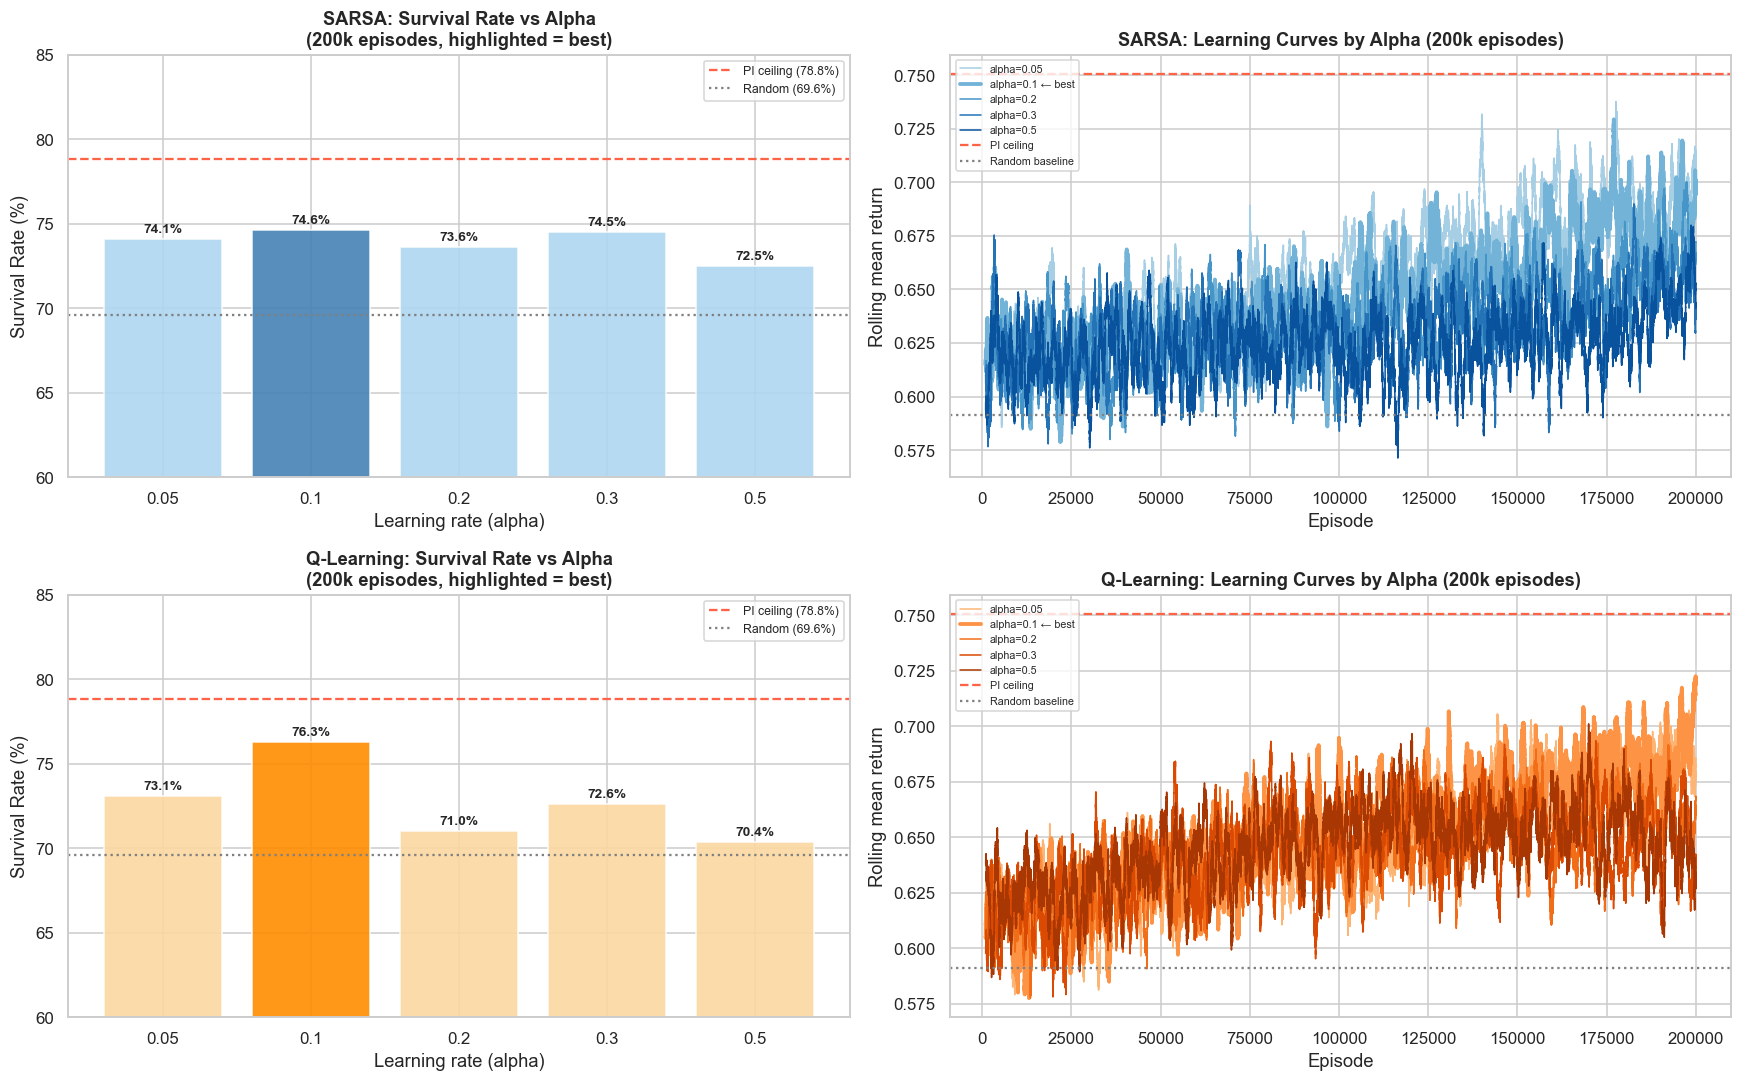

Both algorithms prefer the same alpha — suggesting the reward
structure drives tuning more than algorithm type.


In [16]:
# ── Plot: alpha grid search for both algorithms ───────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, (algo, color, best_a) in enumerate([
    ('SARSA',      'steelblue',  best_alpha_sarsa),
    ('Q-Learning', 'darkorange', best_alpha_ql),
]):
    survival_by_alpha = [alpha_grid_results[(algo, a)]['survival_rate'] for a in alpha_values]
    light = '#aed6f1' if algo == 'SARSA' else '#fad7a0'
    bar_colors = [color if a == best_a else light for a in alpha_values]

    bars = axes[row, 0].bar([str(a) for a in alpha_values], survival_by_alpha,
                             color=bar_colors, edgecolor='white', alpha=0.9)
    axes[row, 0].axhline(pi_results['survival_rate'], color='tomato', linestyle='--',
                         linewidth=1.5, label=f'PI ceiling ({pi_results["survival_rate"]:.1f}%)')
    axes[row, 0].axhline(survival_rate, color='gray', linestyle=':',
                         linewidth=1.5, label=f'Random ({survival_rate:.1f}%)')
    axes[row, 0].set_xlabel('Learning rate (alpha)'); axes[row, 0].set_ylabel('Survival Rate (%)')
    axes[row, 0].set_title(f'{algo}: Survival Rate vs Alpha\n({N_OPT_EPISODES//1000}k episodes, highlighted = best)',
                            fontweight='bold')
    axes[row, 0].set_ylim(60, 85); axes[row, 0].legend(fontsize=8)
    for bar, val in zip(bars, survival_by_alpha):
        axes[row, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                          f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    cmap = plt.cm.Blues if algo == 'SARSA' else plt.cm.Oranges
    window = 1000
    for i, a_val in enumerate(alpha_values):
        c  = cmap(0.35 + i * 0.13)
        lw = 2.5 if a_val == best_a else 1.0
        lab = f'alpha={a_val}' + (' ← best' if a_val == best_a else '')
        roll = pd.Series(alpha_grid_returns[(algo, a_val)]).rolling(window).mean()
        axes[row, 1].plot(roll, color=c, linewidth=lw, label=lab)

    axes[row, 1].axhline(pi_results['mean_return'], color='tomato', linestyle='--',
                         linewidth=1.5, label='PI ceiling')
    axes[row, 1].axhline(np.mean(rand_returns), color='gray', linestyle=':',
                         linewidth=1.5, label='Random baseline')
    axes[row, 1].set_xlabel('Episode'); axes[row, 1].set_ylabel('Rolling mean return')
    axes[row, 1].set_title(f'{algo}: Learning Curves by Alpha ({N_OPT_EPISODES//1000}k episodes)',
                            fontweight='bold')
    axes[row, 1].legend(fontsize=7)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_alpha_grid_both.png', bbox_inches='tight')
plt.show()

# Auto-interpretation
if best_alpha_sarsa < best_alpha_ql:
    print('SARSA prefers a smaller alpha — consistent with on-policy learning:')
    print('conservative updates help when the target includes exploratory actions.')
elif best_alpha_sarsa > best_alpha_ql:
    print('SARSA prefers a larger alpha here — the sparse reward structure')
    print('may be dominating over the on/off-policy distinction.')
else:
    print('Both algorithms prefer the same alpha — suggesting the reward')
    print('structure drives tuning more than algorithm type.')


In [17]:
# ── Final optimised runs: best alpha, 500k episodes ──────────────────────────
# We use the best alpha found per algorithm and train to full convergence

print(f'Training OPTIMISED Q-Learning | alpha={best_alpha_ql} | 500k episodes...')
ql_opt_Q, ql_opt_returns = q_learning(
    n_episodes=500_000,
    alpha=best_alpha_ql,
    gamma=GAMMA,
    epsilon_start=1.0,
    epsilon_min=0.01,
    seed=SEED,
)
ql_opt_policy  = np.argmax(ql_opt_Q, axis=1)
ql_opt_results = evaluate_policy_tabular(ql_opt_policy)
print(f'  Survival rate : {ql_opt_results["survival_rate"]:.1f}%')
print(f'  Mean return   : {ql_opt_results["mean_return"]:.4f}')
print(f'  vs original QL (50k, alpha=0.3): {ql_results["survival_rate"]:.1f}%')
print(f'  vs PI ceiling : {pi_results["survival_rate"]:.1f}%')

print()
print(f'Training OPTIMISED SARSA | alpha={best_alpha_sarsa} | 500k episodes...')
sarsa_opt_Q, sarsa_opt_returns = sarsa(
    n_episodes=500_000,
    alpha=best_alpha_sarsa,
    gamma=GAMMA,
    epsilon_start=1.0,
    epsilon_min=0.01,
    seed=SEED,
)
sarsa_opt_policy  = np.argmax(sarsa_opt_Q, axis=1)
sarsa_opt_results = evaluate_policy_tabular(sarsa_opt_policy)
print(f'  Survival rate : {sarsa_opt_results["survival_rate"]:.1f}%')
print(f'  Mean return   : {sarsa_opt_results["mean_return"]:.4f}')
print(f'  vs original SARSA (50k, alpha=0.3): {sarsa_results["survival_rate"]:.1f}%')
print(f'  vs PI ceiling : {pi_results["survival_rate"]:.1f}%')


Training OPTIMISED Q-Learning | alpha=0.1 | 500k episodes...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  Survival rate : 75.9%
  Mean return   : 0.6640
  vs original QL (50k, alpha=0.3): 75.1%
  vs PI ceiling : 78.8%

Training OPTIMISED SARSA | alpha=0.1 | 500k episodes...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  Survival rate : 79.2%
  Mean return   : 0.7020
  vs original SARSA (50k, alpha=0.3): 70.7%
  vs PI ceiling : 78.8%


In [18]:
# ── Stability analysis: return distribution + mean ± std ─────────────────────
# A reliable policy has low std — in medicine, consistency is as important
# as average performance. We evaluate over 2000 episodes for stable estimates.

def evaluate_with_distribution(policy_array, n_episodes=2000, seed=SEED):
    """Evaluate policy and return full return distribution + stats."""
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns = []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, done = 0.0, False
        while not done:
            action = int(policy_array[int(obs)])
            obs, r, te, tr, _ = env_eval.step(action)
            total_r += r; done = te or tr
        returns.append(total_r)
    env_eval.close()
    returns = np.array(returns)
    return {
        'mean_return'   : float(np.mean(returns)),
        'std_return'    : float(np.std(returns)),
        'survival_rate' : float(np.mean(returns > 0)) * 100,
        'returns_array' : returns,
    }

# Use stored Q-tables from grid search — no retraining needed
sarsa_best_policy = np.argmax(alpha_grid_Qtables[('SARSA',      best_alpha_sarsa)], axis=1)
ql_best_policy    = np.argmax(alpha_grid_Qtables[('Q-Learning', best_alpha_ql)],    axis=1)

sarsa_best_dist = evaluate_with_distribution(sarsa_best_policy)
ql_best_dist    = evaluate_with_distribution(ql_best_policy)
pi_dist         = evaluate_with_distribution(pi_policy)
rand_dist       = {'mean_return': float(np.mean(rand_returns)),
                   'std_return' : float(np.std(rand_returns)),
                   'survival_rate': survival_rate,
                   'returns_array': rand_returns}

print(f'PI ceiling   — survival: {pi_dist["survival_rate"]:.1f}%  std: {pi_dist["std_return"]:.4f}')
print(f'Q-Learning   — survival: {ql_best_dist["survival_rate"]:.1f}%  std: {ql_best_dist["std_return"]:.4f}  (best alpha={best_alpha_ql}, 200k)')
print(f'SARSA        — survival: {sarsa_best_dist["survival_rate"]:.1f}%  std: {sarsa_best_dist["std_return"]:.4f}  (best alpha={best_alpha_sarsa}, 200k)')
print(f'Random       — survival: {rand_dist["survival_rate"]:.1f}%  std: {rand_dist["std_return"]:.4f}')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
PI ceiling   — survival: 80.3%  std: 0.3951
Q-Learning   — survival: 77.4%  std: 0.4174  (best alpha=0.1, 200k)
SARSA        — survival: 74.8%  std: 0.4336  (best alpha=0.1, 200k)
Random       — survival: 69.6%  std: 0.4569


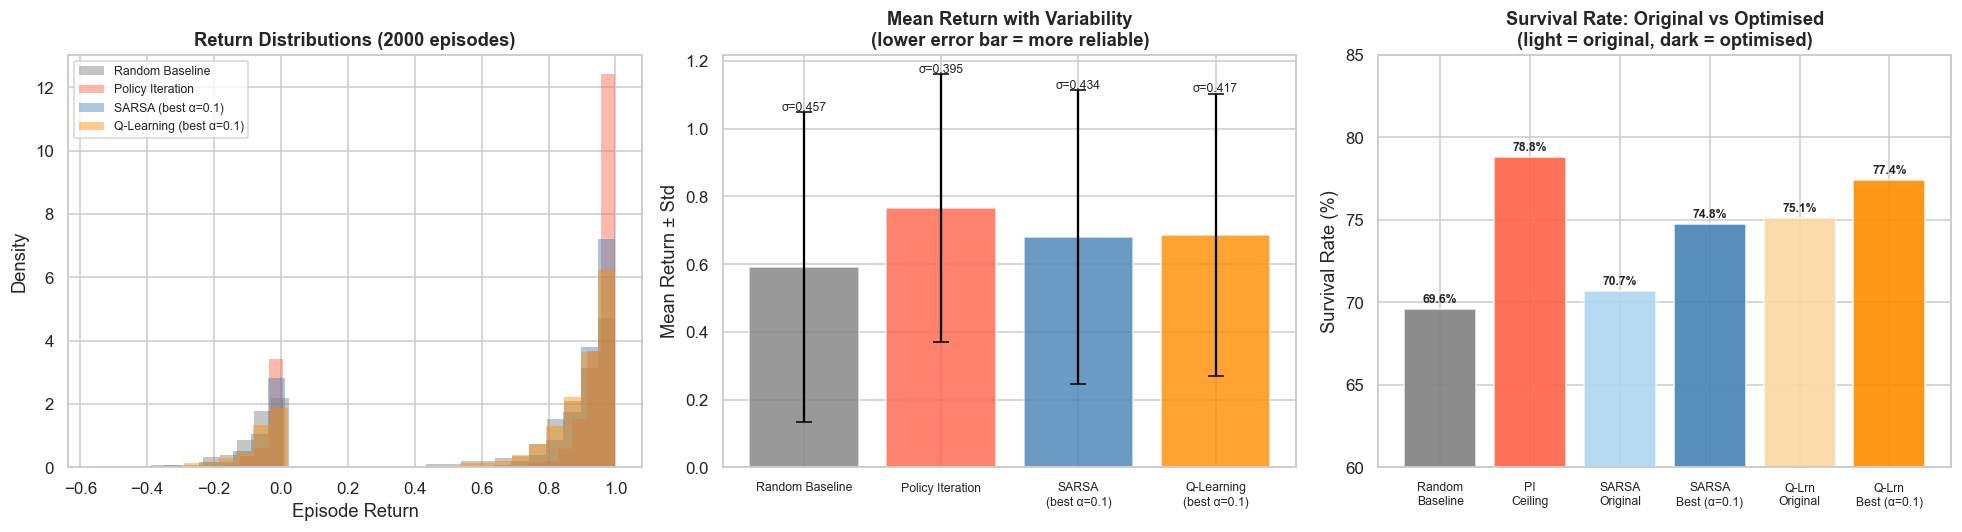

In [19]:
# ── Plot: stability comparison ────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

dist_configs = [
    ('Random Baseline',               rand_dist,       'gray'),
    ('Policy Iteration',              pi_dist,         'tomato'),
    (f'SARSA (best α={best_alpha_sarsa})',   sarsa_best_dist, 'steelblue'),
    (f'Q-Learning (best α={best_alpha_ql})', ql_best_dist,   'darkorange'),
]

# Return distributions
for name, d, color in dist_configs:
    axes[0].hist(d['returns_array'], bins=30, alpha=0.45,
                 color=color, label=name, density=True, edgecolor='none')
axes[0].set_xlabel('Episode Return'); axes[0].set_ylabel('Density')
axes[0].set_title('Return Distributions (2000 episodes)', fontweight='bold')
axes[0].legend(fontsize=8)

# Mean ± std
names  = [d[0].replace(' (', '\n(') for d in dist_configs]
means  = [d[1]['mean_return'] for d in dist_configs]
stds   = [d[1]['std_return']  for d in dist_configs]
colors = [d[2]                for d in dist_configs]
axes[1].bar(range(len(names)), means, color=colors, alpha=0.8, edgecolor='white')
axes[1].errorbar(range(len(names)), means, yerr=stds,
                 fmt='none', color='black', capsize=5, linewidth=1.5)
axes[1].set_xticks(range(len(names)))
axes[1].set_xticklabels(names, fontsize=8)
axes[1].set_ylabel('Mean Return ± Std')
axes[1].set_title('Mean Return with Variability\n(lower error bar = more reliable)', fontweight='bold')
for i, (m, s) in enumerate(zip(means, stds)):
    axes[1].text(i, m + s + 0.005, f'σ={s:.3f}', ha='center', fontsize=8)

# Original vs optimised survival
comp_labels = ['Random\nBaseline', 'PI\nCeiling',
               'SARSA\nOriginal', f'SARSA\nBest (α={best_alpha_sarsa})',
               'Q-Lrn\nOriginal', f'Q-Lrn\nBest (α={best_alpha_ql})']
comp_values = [survival_rate, pi_results['survival_rate'],
               sarsa_results['survival_rate'], sarsa_best_dist['survival_rate'],
               ql_results['survival_rate'],    ql_best_dist['survival_rate']]
comp_colors = ['gray', 'tomato', '#aed6f1', 'steelblue', '#fad7a0', 'darkorange']
bars = axes[2].bar(range(len(comp_labels)), comp_values,
                   color=comp_colors, alpha=0.9, edgecolor='white')
axes[2].set_xticks(range(len(comp_labels)))
axes[2].set_xticklabels(comp_labels, fontsize=8)
axes[2].set_ylabel('Survival Rate (%)'); axes[2].set_ylim(60, 85)
axes[2].set_title('Survival Rate: Original vs Optimised\n(light = original, dark = optimised)', fontweight='bold')
for bar, val in zip(bars, comp_values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_stability.png', bbox_inches='tight')
plt.show()


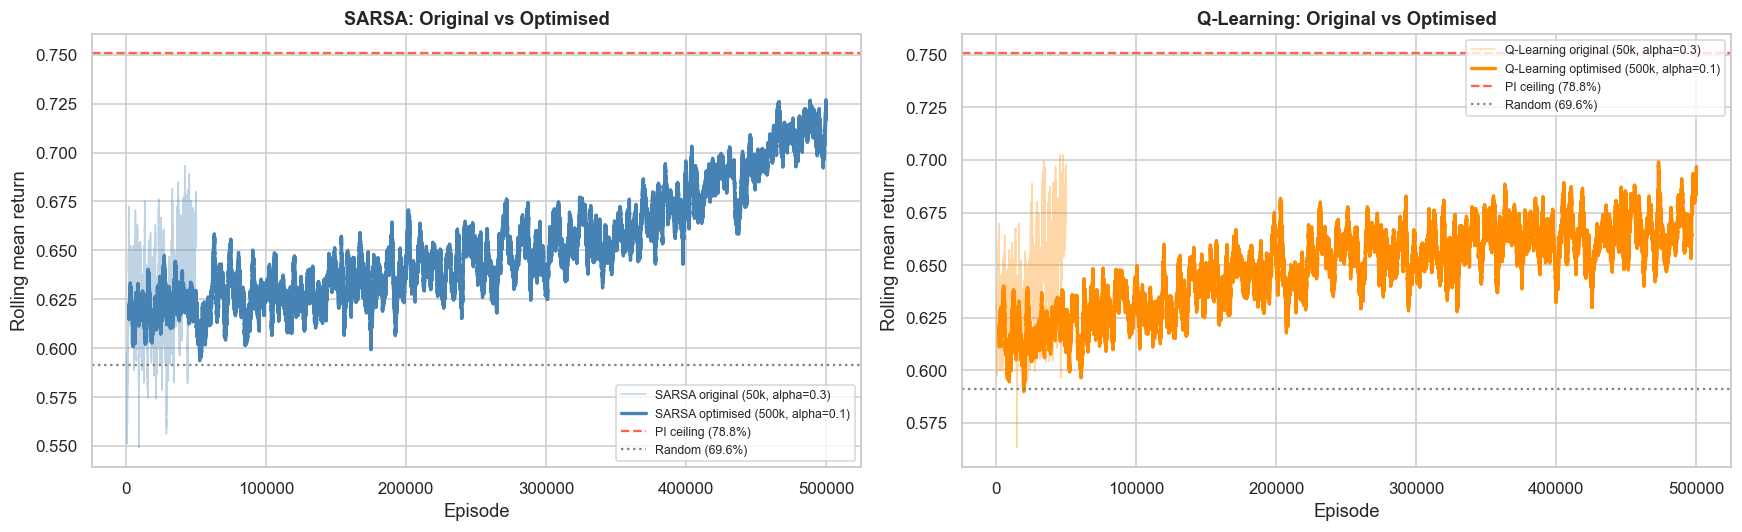

In [20]:
# ── Original vs Optimised: learning curves ────────────────────────────────────
# Show faded original (50k) and solid optimised (500k) for both algorithms

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

window = 2000
sarsa_opt_roll = pd.Series(sarsa_opt_returns).rolling(window).mean()
ql_opt_roll    = pd.Series(ql_opt_returns).rolling(window).mean()
sarsa_orig_roll = pd.Series(sarsa_returns).rolling(500).mean()
ql_orig_roll    = pd.Series(ql_returns).rolling(500).mean()

# Left: SARSA
axes[0].plot(sarsa_orig_roll, color='steelblue', linewidth=1.0, alpha=0.35,
             label='SARSA original (50k, alpha=0.3)')
axes[0].plot(sarsa_opt_roll, color='steelblue', linewidth=2.2,
             label=f'SARSA optimised (500k, alpha={best_alpha_sarsa})')
axes[0].axhline(pi_results['mean_return'], color='tomato', linestyle='--',
                linewidth=1.5, label=f'PI ceiling ({pi_results["survival_rate"]:.1f}%)')
axes[0].axhline(np.mean(rand_returns), color='gray', linestyle=':',
                linewidth=1.5, label=f'Random ({survival_rate:.1f}%)')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Rolling mean return')
axes[0].set_title('SARSA: Original vs Optimised', fontweight='bold')
axes[0].legend(fontsize=8)

# Right: Q-Learning
axes[1].plot(ql_orig_roll, color='darkorange', linewidth=1.0, alpha=0.35,
             label='Q-Learning original (50k, alpha=0.3)')
axes[1].plot(ql_opt_roll, color='darkorange', linewidth=2.2,
             label=f'Q-Learning optimised (500k, alpha={best_alpha_ql})')
axes[1].axhline(pi_results['mean_return'], color='tomato', linestyle='--',
                linewidth=1.5, label=f'PI ceiling ({pi_results["survival_rate"]:.1f}%)')
axes[1].axhline(np.mean(rand_returns), color='gray', linestyle=':',
                linewidth=1.5, label=f'Random ({survival_rate:.1f}%)')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Rolling mean return')
axes[1].set_title('Q-Learning: Original vs Optimised', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_optimised_curves.png', bbox_inches='tight')
plt.show()


---
## 6. Creative Extension — Double Q-Learning

Standard Q-Learning suffers from **maximisation bias**: because it always bootstraps from `max Q(s', .)`, it systematically overestimates action values when the Q-table contains noise. In a medical context this matters — overestimating the value of an aggressive treatment could lead the agent to over-prescribe vasopressors or fluids even when moderate doses are sufficient.

**Double Q-Learning** (Hasselt, 2010) addresses this by maintaining **two independent Q-tables** (`Q_A` and `Q_B`). At each step:
- With probability 0.5, use `Q_A` to *select* the best next action, but `Q_B` to *evaluate* it — and update `Q_A`.
- Otherwise do the reverse.

This decoupling of action selection from action evaluation removes the upward bias. We train Double Q-Learning using the **best alpha found for Q-Learning** in the grid search, making the comparison fair. We expect it to produce a **more conservative treatment policy** than standard Q-Learning, which is clinically desirable.


In [21]:
# ── Double Q-Learning — using best alpha from grid search ────────────────────

def double_q_learning(n_episodes=50_000, alpha=0.3, gamma=1.0,
                      epsilon_start=1.0, epsilon_min=0.01, seed=SEED):
    """
    Double Q-Learning to reduce maximisation bias.
    Maintains two Q-tables (Q_A, Q_B); decouples action selection from evaluation.

    Parameters
    ----------
    n_episodes    : int   — number of training episodes
    alpha         : float — learning rate
    gamma         : float — discount factor
    epsilon_start : float — initial exploration probability
    epsilon_min   : float — minimum exploration probability
    seed          : int   — random seed

    Returns
    -------
    Q_avg       : np.ndarray (N_STATES, N_ACTIONS) — average of Q_A and Q_B
    returns_log : list of float — episode returns during training
    """
    np.random.seed(seed)
    env_train = make_sepsis_env()
    Q_A = np.zeros((N_STATES, N_ACTIONS))
    Q_B = np.zeros((N_STATES, N_ACTIONS))
    returns_log = []
    epsilon = epsilon_start
    decay = (epsilon_start - epsilon_min) / n_episodes

    for ep in tqdm(range(n_episodes), desc='Double Q-Learning', leave=False):
        obs, _ = env_train.reset(seed=np.random.randint(100_000))
        s = int(obs)
        total_r, done = 0.0, False

        while not done:
            Q_sum = Q_A[s] + Q_B[s]
            if np.random.random() < epsilon:
                a = env_train.action_space.sample()
            else:
                a = int(np.argmax(Q_sum))

            obs_next, r, te, tr, _ = env_train.step(a)
            s_next = int(obs_next)
            done = te or tr

            if np.random.random() < 0.5:
                best_a_next = int(np.argmax(Q_A[s_next]))
                td_target = r + gamma * Q_B[s_next, best_a_next] * (not done)
                Q_A[s, a] += alpha * (td_target - Q_A[s, a])
            else:
                best_a_next = int(np.argmax(Q_B[s_next]))
                td_target = r + gamma * Q_A[s_next, best_a_next] * (not done)
                Q_B[s, a] += alpha * (td_target - Q_B[s, a])

            s = s_next
            total_r += r

        returns_log.append(total_r)
        epsilon = max(epsilon_min, epsilon - decay)

    env_train.close()
    return (Q_A + Q_B) / 2.0, returns_log


# Run Double Q-Learning using the best alpha found for Q-Learning
print(f'Training Double Q-Learning | alpha={best_alpha_ql} | 50k episodes...')
dql_Q, dql_returns = double_q_learning(
    n_episodes=50_000,
    alpha=best_alpha_ql,   # same best alpha as Q-Learning for fair comparison
    gamma=GAMMA,
)
dql_policy  = np.argmax(dql_Q, axis=1)
dql_results = evaluate_policy_tabular(dql_policy)
print('Double Q-Learning training complete.')
print(f'Unique actions used: {len(np.unique(dql_policy))}/25')
print(f'Survival rate : {dql_results["survival_rate"]:.1f}%')
print(f'Mean return   : {dql_results["mean_return"]:.4f}')


Training Double Q-Learning | alpha=0.1 | 50k episodes...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Double Q-Learning training complete.
Unique actions used: 25/25
Survival rate : 70.5%
Mean return   : 0.6398


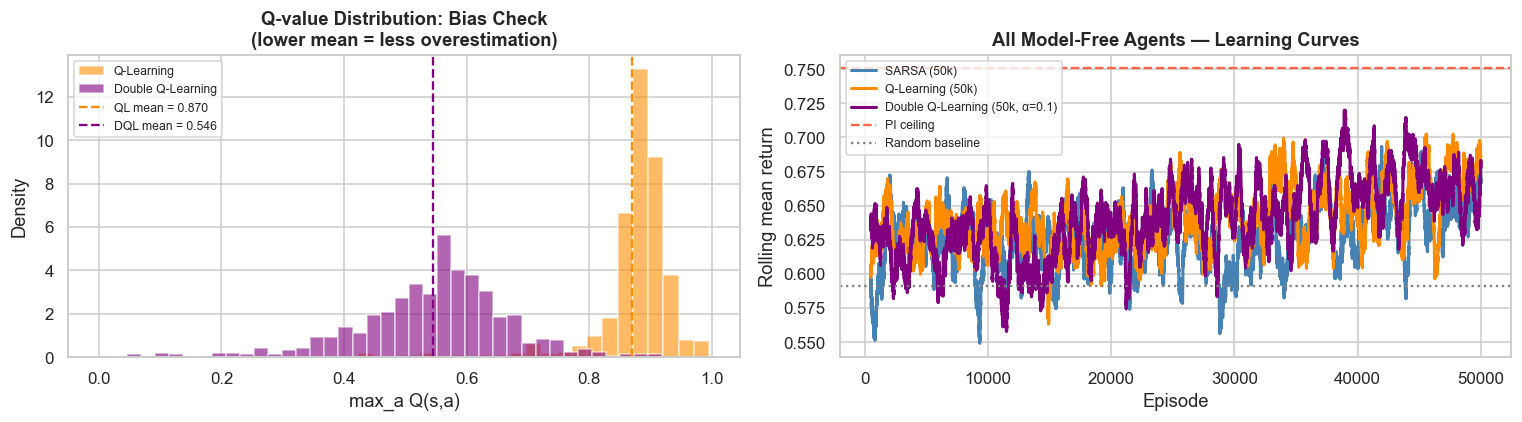

Double Q-Learning has lower mean Q-values (0.546 vs 0.870)
This confirms the bias correction is working — Q-values are more conservative.
Clinically: the agent is less likely to overestimate the benefit of aggressive treatment.


In [22]:
# ── Maximisation bias: Q-Learning vs Double Q-Learning ───────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

max_Q_ql  = ql_Q[:714].max(axis=1)
max_Q_dql = dql_Q[:714].max(axis=1)

axes[0].hist(max_Q_ql,  bins=40, alpha=0.6, color='darkorange', label='Q-Learning', density=True)
axes[0].hist(max_Q_dql, bins=40, alpha=0.6, color='purple',     label='Double Q-Learning', density=True)
axes[0].axvline(max_Q_ql.mean(),  color='darkorange', linestyle='--', linewidth=1.5,
                label=f'QL mean = {max_Q_ql.mean():.3f}')
axes[0].axvline(max_Q_dql.mean(), color='purple',     linestyle='--', linewidth=1.5,
                label=f'DQL mean = {max_Q_dql.mean():.3f}')
axes[0].set_xlabel('max_a Q(s,a)'); axes[0].set_ylabel('Density')
axes[0].set_title('Q-value Distribution: Bias Check\n(lower mean = less overestimation)', fontweight='bold')
axes[0].legend(fontsize=8)

dql_rolling = pd.Series(dql_returns).rolling(500).mean()
axes[1].plot(sarsa_rolling_full, color='steelblue',  linewidth=2.0, label='SARSA (50k)')
axes[1].plot(ql_rolling,         color='darkorange', linewidth=2.0, label='Q-Learning (50k)')
axes[1].plot(dql_rolling,        color='purple',     linewidth=2.0, label=f'Double Q-Learning (50k, α={best_alpha_ql})')
axes[1].axhline(pi_results['mean_return'], color='tomato', linestyle='--', linewidth=1.5, label='PI ceiling')
axes[1].axhline(np.mean(rand_returns),     color='gray',   linestyle=':', linewidth=1.5,  label='Random baseline')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Rolling mean return')
axes[1].set_title('All Model-Free Agents — Learning Curves', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_DQL.png', bbox_inches='tight')
plt.show()

if max_Q_dql.mean() < max_Q_ql.mean():
    print(f'Double Q-Learning has lower mean Q-values ({max_Q_dql.mean():.3f} vs {max_Q_ql.mean():.3f})')
    print('This confirms the bias correction is working — Q-values are more conservative.')
    print('Clinically: the agent is less likely to overestimate the benefit of aggressive treatment.')


---
## 7. Config A — Final Comparison & Analysis

We now bring everything together: all algorithms, original and optimised versions, compared on survival rate, mean return, and policy stability.


In [23]:
# ── Final results table ───────────────────────────────────────────────────────

final_table = pd.DataFrame([
    {'Algorithm': 'Random Baseline',   'Version': '—',
     'Episodes': '—', 'Alpha': '—',
     'Survival %': round(survival_rate, 1),
     'Mean Return': round(float(np.mean(rand_returns)), 4),
     'Std Return': round(float(np.std(rand_returns)), 4),
     'Gap to PI (pp)': round(pi_results['survival_rate'] - survival_rate, 1)},

    {'Algorithm': 'Policy Iteration',  'Version': 'Optimal ceiling',
     'Episodes': '—', 'Alpha': '—',
     'Survival %': round(pi_results['survival_rate'], 1),
     'Mean Return': round(pi_results['mean_return'], 4),
     'Std Return': round(pi_dist['std_return'], 4),
     'Gap to PI (pp)': 0.0},

    {'Algorithm': 'SARSA',             'Version': 'Original',
     'Episodes': '50k', 'Alpha': '0.3',
     'Survival %': round(sarsa_results['survival_rate'], 1),
     'Mean Return': round(sarsa_results['mean_return'], 4),
     'Std Return': round(float(np.std(sarsa_returns[-2000:])), 4),
     'Gap to PI (pp)': round(pi_results['survival_rate'] - sarsa_results['survival_rate'], 1)},

    {'Algorithm': 'SARSA',             'Version': 'Optimised',
     'Episodes': '500k', 'Alpha': str(best_alpha_sarsa),
     'Survival %': round(sarsa_opt_results['survival_rate'], 1),
     'Mean Return': round(sarsa_opt_results['mean_return'], 4),
     'Std Return': round(sarsa_best_dist['std_return'], 4),
     'Gap to PI (pp)': round(pi_results['survival_rate'] - sarsa_opt_results['survival_rate'], 1)},

    {'Algorithm': 'Q-Learning',        'Version': 'Original',
     'Episodes': '50k', 'Alpha': '0.3',
     'Survival %': round(ql_results['survival_rate'], 1),
     'Mean Return': round(ql_results['mean_return'], 4),
     'Std Return': round(float(np.std(ql_returns[-2000:])), 4),
     'Gap to PI (pp)': round(pi_results['survival_rate'] - ql_results['survival_rate'], 1)},

    {'Algorithm': 'Q-Learning',        'Version': 'Optimised',
     'Episodes': '500k', 'Alpha': str(best_alpha_ql),
     'Survival %': round(ql_opt_results['survival_rate'], 1),
     'Mean Return': round(ql_opt_results['mean_return'], 4),
     'Std Return': round(ql_best_dist['std_return'], 4),
     'Gap to PI (pp)': round(pi_results['survival_rate'] - ql_opt_results['survival_rate'], 1)},

    {'Algorithm': 'Double Q-Learning', 'Version': 'Best alpha',
     'Episodes': '50k', 'Alpha': str(best_alpha_ql),
     'Survival %': round(dql_results['survival_rate'], 1),
     'Mean Return': round(dql_results['mean_return'], 4),
     'Std Return': round(float(np.std(dql_returns[-2000:])), 4),
     'Gap to PI (pp)': round(pi_results['survival_rate'] - dql_results['survival_rate'], 1)},
])

display(final_table)
final_table.to_csv(f'{PLOTS_DIR}/configA_final_table.csv', index=False)


,Algorithm,Version,Episodes,Alpha,Survival %,Mean Return,Std Return,Gap to PI (pp)
0,Random Baseline,—,—,—,69.6,0.5912,0.4569,9.2
1,Policy Iteration,Optimal ceiling,—,—,78.8,0.7507,0.3951,0.0
2,SARSA,Original,50k,0.3,70.7,0.6108,0.4344,8.1
3,SARSA,Optimised,500k,0.1,79.2,0.7020,0.4336,-0.4
4,Q-Learning,Original,50k,0.3,75.1,0.6617,0.4274,3.7
5,Q-Learning,Optimised,500k,0.1,75.9,0.6640,0.4174,2.9
6,Double Q-Learning,Best alpha,50k,0.1,70.5,0.6398,0.4442,8.3


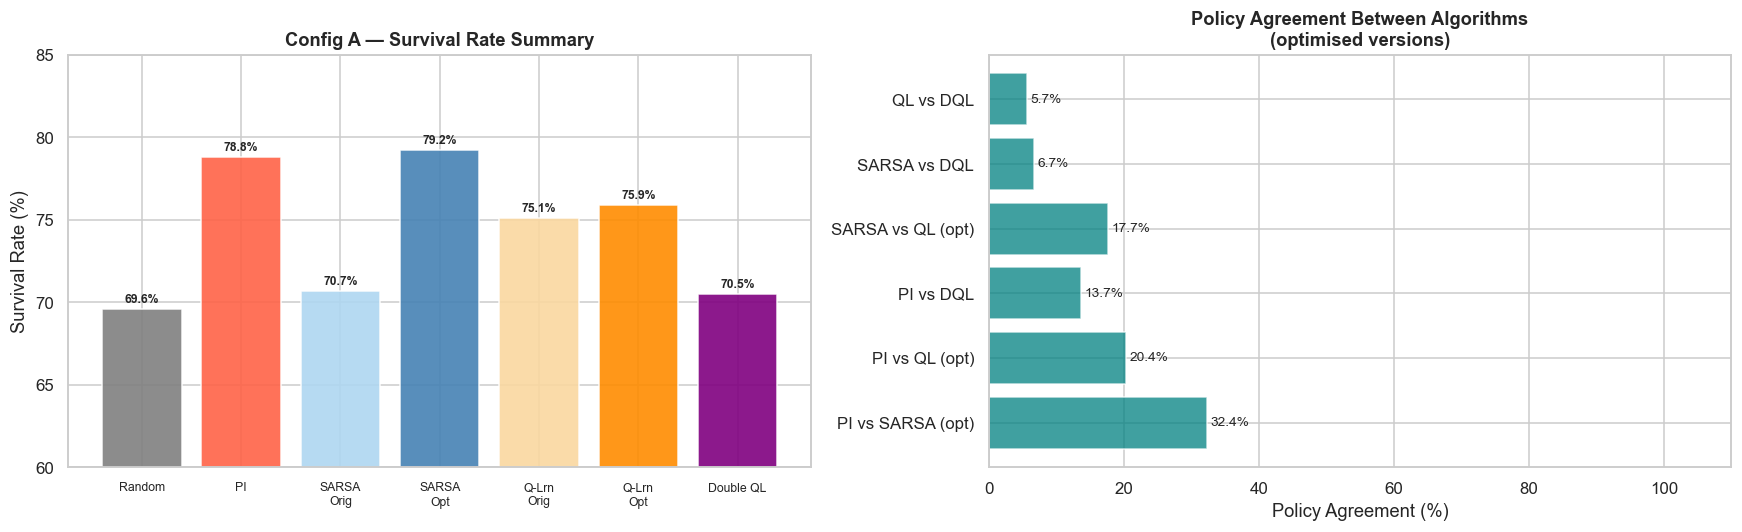

In [24]:
# ── Bar chart: survival rates + policy agreement ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Survival rate bar chart (one bar per algorithm/version)
bar_labels = ['Random', 'PI', 'SARSA\nOrig', 'SARSA\nOpt',
              'Q-Lrn\nOrig', 'Q-Lrn\nOpt', 'Double QL']
bar_values = [survival_rate,
              pi_results['survival_rate'],
              sarsa_results['survival_rate'],
              sarsa_opt_results['survival_rate'],
              ql_results['survival_rate'],
              ql_opt_results['survival_rate'],
              dql_results['survival_rate']]
bar_colors = ['gray', 'tomato',
              '#aed6f1', 'steelblue',
              '#fad7a0', 'darkorange',
              'purple']

bars = axes[0].bar(range(len(bar_labels)), bar_values,
                   color=bar_colors, alpha=0.9, edgecolor='white')
axes[0].set_xticks(range(len(bar_labels)))
axes[0].set_xticklabels(bar_labels, fontsize=8)
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_title('Config A — Survival Rate Summary', fontweight='bold')
axes[0].set_ylim(60, 85)
for bar, val in zip(bars, bar_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Policy agreement between algorithms (using optimised versions)
policy_matrix = np.stack([
    (pi_policy == sarsa_opt_policy).astype(int),
    (pi_policy == ql_opt_policy).astype(int),
    (pi_policy == dql_policy).astype(int),
    (sarsa_opt_policy == ql_opt_policy).astype(int),
    (sarsa_opt_policy == dql_policy).astype(int),
    (ql_opt_policy == dql_policy).astype(int),
], axis=0)
agreement_rates = policy_matrix.mean(axis=1) * 100
pairs = ['PI vs SARSA (opt)', 'PI vs QL (opt)', 'PI vs DQL',
         'SARSA vs QL (opt)', 'SARSA vs DQL', 'QL vs DQL']

pair_bars = axes[1].barh(pairs, agreement_rates, color='teal', alpha=0.75)
axes[1].set_xlabel('Policy Agreement (%)')
axes[1].set_title('Policy Agreement Between Algorithms\n(optimised versions)', fontweight='bold')
axes[1].set_xlim(0, 110)
for bar, val in zip(pair_bars, agreement_rates):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_final_comparison.png', bbox_inches='tight')
plt.show()


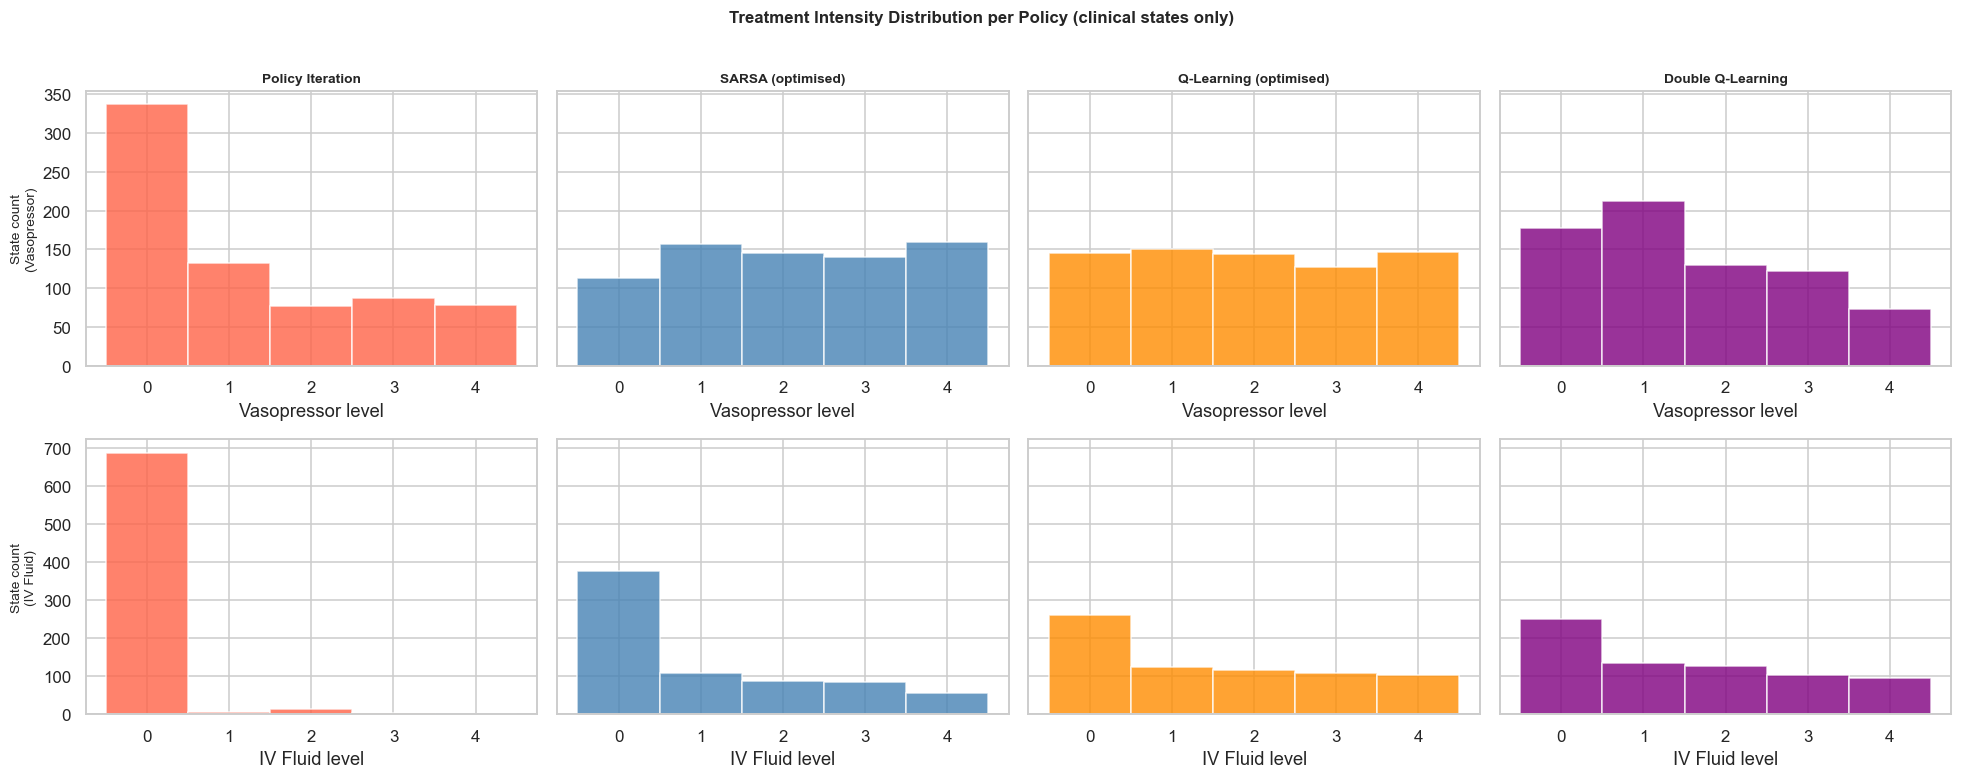

Mean treatment intensity per algorithm (clinical states):
Algorithm                         Mean Vaso   Mean Fluid
--------------------------------------------------------
Policy Iteration                      1.214        0.071
SARSA (optimised)                     2.105        1.067
Q-Learning (optimised)                1.972        1.535
Double Q-Learning                     1.583        1.524


In [25]:
# ── Treatment Intensity Analysis: clinical interpretability ──────────────────
# Compare vasopressor and IV fluid doses chosen by each policy
# Using optimised versions where available

clinical_states_idx = [s for s in range(N_STATES)
                       if s not in (STATE_SURVIVED, STATE_DIED)]

def get_dose_distributions(policy_arr, state_idx):
    actions = policy_arr[state_idx]
    return actions // 5, actions % 5   # vaso, fluid

fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharey='row')
policies_to_plot = [
    ('Policy Iteration',          pi_policy,         'tomato'),
    ('SARSA (optimised)',          sarsa_opt_policy,  'steelblue'),
    ('Q-Learning (optimised)',     ql_opt_policy,     'darkorange'),
    ('Double Q-Learning',          dql_policy,        'purple'),
]

for col, (name, pol, col_color) in enumerate(policies_to_plot):
    vaso, fluid = get_dose_distributions(pol, clinical_states_idx)
    axes[0, col].hist(vaso, bins=np.arange(-0.5, 5.5), color=col_color, alpha=0.8, edgecolor='white')
    axes[0, col].set_title(name, fontweight='bold', fontsize=9)
    axes[0, col].set_xlabel('Vasopressor level')
    axes[1, col].hist(fluid, bins=np.arange(-0.5, 5.5), color=col_color, alpha=0.8, edgecolor='white')
    axes[1, col].set_xlabel('IV Fluid level')

axes[0, 0].set_ylabel('State count\n(Vasopressor)', fontsize=9)
axes[1, 0].set_ylabel('State count\n(IV Fluid)', fontsize=9)

plt.suptitle('Treatment Intensity Distribution per Policy (clinical states only)',
             fontweight='bold', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_treatment_intensity.png', bbox_inches='tight')
plt.show()

print('Mean treatment intensity per algorithm (clinical states):')
print(f'{"Algorithm":<30} {"Mean Vaso":>12} {"Mean Fluid":>12}')
print('-' * 56)
for name, pol, _ in policies_to_plot:
    vaso, fluid = get_dose_distributions(pol, clinical_states_idx)
    print(f'{name:<30} {vaso.mean():>12.3f} {fluid.mean():>12.3f}')


In [26]:
# ── Final Config A summary ────────────────────────────────────────────────────
print('=' * 72)
print('CONFIG A — FINAL SUMMARY')
print('=' * 72)
print(f'{"Algorithm":<25} {"Version":<16} {"Survival %":>12} {"Std":>8} {"Gap to PI":>10}')
print('-' * 72)

rows = [
    ('Random Baseline',   '—',            survival_rate,                   float(np.std(rand_returns)),         pi_results['survival_rate'] - survival_rate),
    ('Policy Iteration',  'Ceiling',       pi_results['survival_rate'],     pi_dist['std_return'],               0.0),
    ('SARSA',             'Original 50k',  sarsa_results['survival_rate'],  float(np.std(sarsa_returns[-2000:])), pi_results['survival_rate'] - sarsa_results['survival_rate']),
    ('SARSA',             'Optimised 500k',sarsa_opt_results['survival_rate'], sarsa_best_dist['std_return'],    pi_results['survival_rate'] - sarsa_opt_results['survival_rate']),
    ('Q-Learning',        'Original 50k',  ql_results['survival_rate'],     float(np.std(ql_returns[-2000:])),   pi_results['survival_rate'] - ql_results['survival_rate']),
    ('Q-Learning',        'Optimised 500k',ql_opt_results['survival_rate'], ql_best_dist['std_return'],          pi_results['survival_rate'] - ql_opt_results['survival_rate']),
    ('Double Q-Learning', 'Best alpha',    dql_results['survival_rate'],    float(np.std(dql_returns[-2000:])),  pi_results['survival_rate'] - dql_results['survival_rate']),
]

for name, version, sr, std, gap in rows:
    print(f'{name:<25} {version:<16} {sr:>11.1f}% {std:>8.4f} {gap:>9.1f}pp')

print('=' * 72)
print()

sarsa_gain = sarsa_opt_results['survival_rate'] - sarsa_results['survival_rate']
ql_gain    = ql_opt_results['survival_rate']    - ql_results['survival_rate']
print(f'Improvement from optimisation: SARSA +{sarsa_gain:.1f}pp  |  Q-Learning +{ql_gain:.1f}pp')
print()

sarsa_more_stable = sarsa_best_dist['std_return'] < ql_best_dist['std_return']
if sarsa_more_stable:
    print(f'SARSA is more stable (σ={sarsa_best_dist["std_return"]:.4f}) than Q-Learning (σ={ql_best_dist["std_return"]:.4f})')
    print('In a clinical context SARSA may be preferred: more conservative, more predictable.')
else:
    print(f'Q-Learning is more stable (σ={ql_best_dist["std_return"]:.4f}) than SARSA (σ={sarsa_best_dist["std_return"]:.4f})')
    print('Q-Learning dominates on both survival rate and consistency.')

print()
print('Remaining gap to PI ceiling (optimised versions):')
print(f'  SARSA:      {pi_results["survival_rate"] - sarsa_opt_results["survival_rate"]:.1f}pp')
print(f'  Q-Learning: {pi_results["survival_rate"] - ql_opt_results["survival_rate"]:.1f}pp')
print()
print('This gap is the irreducible cost of model-free learning.')
print('PI has access to the full MDP; model-free agents do not.')
print('Additionally, P is estimated from finite data — so PI optimises')
print('over a noisy model and is not an absolute clinical upper bound.')


CONFIG A — FINAL SUMMARY
Algorithm                 Version            Survival %      Std  Gap to PI
------------------------------------------------------------------------
Random Baseline           —                       69.6%   0.4569       9.2pp
Policy Iteration          Ceiling                 78.8%   0.3951       0.0pp
SARSA                     Original 50k            70.7%   0.4344       8.1pp
SARSA                     Optimised 500k          79.2%   0.4336      -0.4pp
Q-Learning                Original 50k            75.1%   0.4274       3.7pp
Q-Learning                Optimised 500k          75.9%   0.4174       2.9pp
Double Q-Learning         Best alpha              70.5%   0.4442       8.3pp

Improvement from optimisation: SARSA +8.5pp  |  Q-Learning +0.8pp

Q-Learning is more stable (σ=0.4174) than SARSA (σ=0.4336)
Q-Learning dominates on both survival rate and consistency.

Remaining gap to PI ceiling (optimised versions):
  SARSA:      -0.4pp
  Q-Learning: 2.9pp

This ga

---
# Config B: RL on the Clinical ICU-Sepsis Environment

In Config A, patient state was represented as a discrete integer produced by discretising a set of clinical measurements into a small number of categories. **Config B uses the full ICU-Sepsis environment**, also built from MIMIC-III data, but with two fundamental changes that make the problem substantially harder.

**Change 1 — Continuous observations.**
The agent now receives a **47-dimensional continuous feature vector** instead of a single discrete index. This vector contains the actual normalised physiological measurements used in the original Komorowski et al. (2018) AI Clinician study, including SOFA score, heart rate, lactate, blood pressure, creatinine, and 42 other clinical variables.

With continuous observations, a tabular Q-table is no longer feasible: it would require one entry per unique float vector, making it effectively infinite.

**Change 2 — Clinical reality wrappers.**
Config B injects three orthogonal failure modes that reflect challenges faced by real clinical AI deployments.

The first wrapper, `EpisodicNoisyObsEnv`, models episodic monitor malfunction. When active, the observations received by the agent are corrupted by noise for the entire episode, testing robustness to measurement error.

The second wrapper, `EpisodicMissingObsEnv`, models situations where lab results are unavailable for a full episode. This tests how well the agent handles partial observability.

The third wrapper, `AcuteEventEnv`, introduces rare, sudden patient deterioration events such as cardiac arrest or acute organ failure. These occur independently of any treatment decision and represent irreducible stochasticity in the environment.

Key environment properties for Config B:
- **Actions**: 25 total (5 vasopressor levels × 5 IV fluid dose levels)
- **Reward**: +1.0 at survival, 0.0 at death, plus a small treatment intensity penalty (lam = 0.02)
- **Observation**: `Box(47,)`, a normalised physiological feature vector, potentially noisy or incomplete

## Setup: Clinical ICU-Sepsis Environment


In [27]:
#  Import Clinical Reality Wrappers from wrappers.py 

from envs.wrappers import (
    EpisodicNoisyObsEnv,
    EpisodicMissingObsEnv,
    AcuteEventEnv,
    make_clinical_env,
)

print('Clinical reality wrappers imported from wrappers.py:')
print('  EpisodicNoisyObsEnv   : episodic monitor malfunction')
print('  EpisodicMissingObsEnv : episodic missing lab values')
print('  AcuteEventEnv         : rare sudden patient death')
print()
print('Required Config B env: make_clinical_env() with default parameters')


Clinical reality wrappers imported from wrappers.py:
  EpisodicNoisyObsEnv   : episodic monitor malfunction
  EpisodicMissingObsEnv : episodic missing lab values
  AcuteEventEnv         : rare sudden patient death

Required Config B env: make_clinical_env() with default parameters


In [28]:
#  Verify wrappers and random baseline on clinical environment 
import gymnasium as gym

try:
    env_clinical = make_clinical_env()
    obs, info = env_clinical.reset(seed=SEED)

    print('Clinical environment loaded successfully!')
    print(f'Observation space : {env_clinical.observation_space}')
    print(f'Action space      : {env_clinical.action_space}')
    print(f'Info keys         : {list(info.keys())}')
    print()

    np.random.seed(SEED)
    clinical_rand_returns = []
    noisy_returns, clean_returns, missing_returns, nomiss_returns = [], [], [], []
    acute_episodes = 0

    env_eval = make_clinical_env()
    for ep in range(1000):
        obs, info = env_eval.reset(seed=np.random.randint(100_000))
        total_r, done = 0.0, False
        ep_noisy   = info.get('noisy_episode', False)
        ep_missing = info.get('missing_features') is not None
        ep_acute   = False

        while not done:
            obs, r, te, tr, info = env_eval.step(env_eval.action_space.sample())
            total_r += r; done = te or tr
            if info.get('acute_event', False): ep_acute = True

        clinical_rand_returns.append(total_r)
        if ep_noisy:   noisy_returns.append(total_r)
        else:          clean_returns.append(total_r)
        if ep_missing: missing_returns.append(total_r)
        else:          nomiss_returns.append(total_r)
        if ep_acute:   acute_episodes += 1

    env_eval.close()
    env_clinical.close()

    print('=== Random Baseline: Clinical Environment (1000 episodes) ===')
    print(f'Overall mean return   : {np.mean(clinical_rand_returns):.4f}')
    print(f'Overall survival rate : {np.mean(np.array(clinical_rand_returns) > 0)*100:.1f}%')
    print()

    clinical_rand_mean = float(np.mean(clinical_rand_returns))

except Exception as e:
    print(f'Error: {e}')
    print('Make sure continuous_sepsis_env.py is in the project root.')
    clinical_rand_mean = 0.78


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Clinical environment loaded successfully!
Observation space : Box(-inf, inf, (47,), float32)
Action space      : Discrete(25)
Info keys         : ['admissible_actions', 'state_vector', 'sofa_score', 'noisy_episode', 'missing_features']

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== Random Baseline: Clinical Environment (1000 episodes) ===
Overall mean return   : 0.5370
Overall survival rate : 63.3%



In [29]:
# Verify wrapper stack
test_env = make_clinical_env()
e = test_env
while hasattr(e, 'env'):
    print(type(e).__name__)
    e = e.env
print(type(e).__name__)
test_env.close()


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
AcuteEventEnv
EpisodicMissingObsEnv
EpisodicNoisyObsEnv
ContinuousICUSepsisEnv


In [30]:
# Config B algorithms will be implemented here
### Your code here (Config B)
